In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import scipy.stats as stats

In [2]:
import pandas as pd


def _scale_columns(df, prefix, include_totals):
    columns = [col for col in df.columns if col.startswith(prefix)]
    if not include_totals:
        total_column = f"{prefix[:-1]}_Total"
        columns = [col for col in columns if col != total_column]
    return columns


def load_and_split_combined_data(csv_path="data_combined_simulated.csv", include_totals=True):
    df = pd.read_csv(csv_path)

    rses_columns = _scale_columns(df, "RSES_", include_totals)
    rssis_columns = _scale_columns(df, "RSSIS_", include_totals)
    iss_columns = _scale_columns(df, "ISS_", include_totals)

    rses = df.loc[:, rses_columns].copy()
    rssis = df.loc[:, rssis_columns].copy()
    iss = df.loc[:, iss_columns].copy()

    used_columns = set(rses.columns) | set(rssis.columns) | set(iss.columns)
    covariates = df.loc[:, ~df.columns.isin(used_columns)].copy()

    return df, rses, rssis, iss, covariates

def _reverse_code_items(frame, max_score):
    rev_cols = [col for col in frame.columns if col.endswith("_REV")]
    if rev_cols:
        frame.loc[:, rev_cols] = (max_score + 1) - frame.loc[:, rev_cols]
    return rev_cols


# Load the combined data and split it into components
df, rses, rssis, iss, covariates = load_and_split_combined_data(
    "data_combined_simulated.csv",
    include_totals=False,
)

# Reverse code items in RSES, RSSIS, and ISS based on column names ending with "_REV"
# Eg: For RSES, response 3 on a 1-4 scale would be reversed to 2 (since 4 + 1 - 3 = 2)
rses_rev_cols = _reverse_code_items(rses, 4)
rssis_rev_cols = _reverse_code_items(rssis, 5)
iss_rev_cols = _reverse_code_items(iss, 5)

if rses_rev_cols:
    df.loc[:, rses_rev_cols] = rses.loc[:, rses_rev_cols]
if rssis_rev_cols:
    df.loc[:, rssis_rev_cols] = rssis.loc[:, rssis_rev_cols]
if iss_rev_cols:
    df.loc[:, iss_rev_cols] = iss.loc[:, iss_rev_cols]


print("!! Data loaded, split, and reverse-coded successfully.")

print(f"full data shape: {df.shape}")
print(f"rses shape: {rses.shape}")
print(f"rssis shape: {rssis.shape}")
print(f"iss shape: {iss.shape}")
print(f"covariates shape: {covariates.shape}")

print("\nCovariate columns:")
print(covariates.columns.tolist())

rses.head(), rssis.head(), iss.head(), covariates.head()

!! Data loaded, split, and reverse-coded successfully.
full data shape: (394, 74)
rses shape: (394, 10)
rssis shape: (394, 36)
iss shape: (394, 24)
covariates shape: (394, 4)

Covariate columns:
['Gender', 'Academic_Year', 'TOPIK_Level', 'Economic_Status']


(   RSES_1  RSES_2  RSES_3_REV  RSES_4  RSES_5_REV  RSES_6  RSES_7  RSES_8_REV  \
 0       3       4           1       4           4       4       4           1   
 1       4       4           4       4           4       3       4           4   
 2       4       3           4       4           4       4       4           4   
 3       2       4           1       3           3       4       4           4   
 4       4       4           4       4           3       1       1           4   
 
    RSES_9_REV  RSES_10_REV  
 0           4            3  
 1           4            4  
 2           4            4  
 3           4            4  
 4           4            2  ,
    RSSIS_1  RSSIS_2  RSSIS_3  RSSIS_4  RSSIS_5  RSSIS_6  RSSIS_7  RSSIS_8  \
 0        1        1        3        3        1        2        2        2   
 1        2        2        1        1        1        1        1        1   
 2        3        2        1        1        2        1        1        4   
 3        2  

In [3]:
covariates.describe()

,Gender,Academic_Year,TOPIK_Level,Economic_Status
count,394.000000,394.000000,394.000000,394.000000
mean,1.522843,2.647208,0.875635,2.137056
std,0.500113,0.954382,0.330418,0.495781
min,1.000000,1.000000,0.000000,1.000000
25%,1.000000,2.000000,1.000000,2.000000
50%,2.000000,2.500000,1.000000,2.000000
75%,2.000000,3.000000,1.000000,2.000000
max,2.000000,4.000000,1.000000,3.000000


In [8]:
group_counts = (
    covariates.groupby(list(covariates.columns))
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print(f"Rows in covariates: {len(covariates)}")
print(f"Distinct groups: {len(group_counts)}")
group_counts.head()

Rows in covariates: 394
Distinct groups: 37


,Gender,Academic_Year,TOPIK_Level,Economic_Status,count
7,1,2,1,2,62
25,2,2,1,2,47
30,2,3,1,2,43
11,1,3,1,2,28
15,1,4,1,2,28


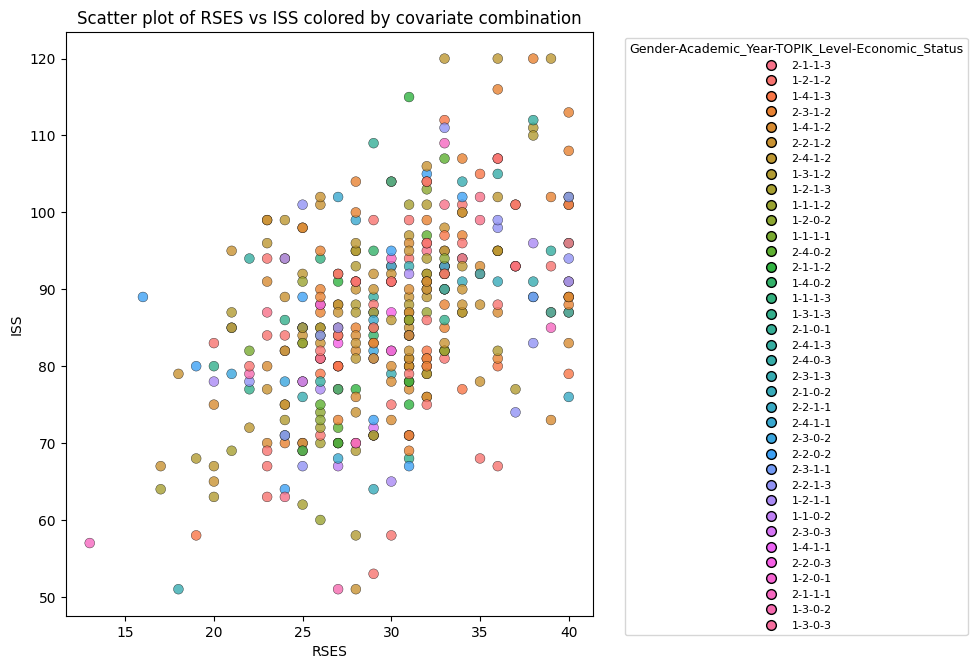

In [ ]:
group_labels = covariates.astype(str).agg("-".join, axis=1)
group_codes, group_names = pd.factorize(group_labels)

palette = sns.color_palette("husl", n_colors=len(group_names))
marker_colors = [palette[i] for i in group_codes]

plt.figure(figsize=(10, 7))
plt.scatter(
    plot_df["RSES"],
    plot_df["ISS"],
    c=marker_colors,
    alpha=0.8,
    s=50,
    edgecolor="black",
    linewidth=0.3,
)

handles = [
    plt.Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor=palette[i],
        markeredgecolor="black",
        markersize=7,
        linestyle=""
    )
    for i in range(len(group_names))
]

# plt.legend(
#     handles,
#     group_names,
#     title="Gender-Academic_Year-TOPIK_Level-Economic_Status",
#     bbox_to_anchor=(1.05, 1),
#     loc="upper left",
#     fontsize=8,
#     title_fontsize=9,
# )

plt.xlabel("RSES")
plt.ylabel("ISS")
plt.title("Scatter plot of RSES vs ISS colored by covariate combination")
plt.tight_layout()
plt.show()

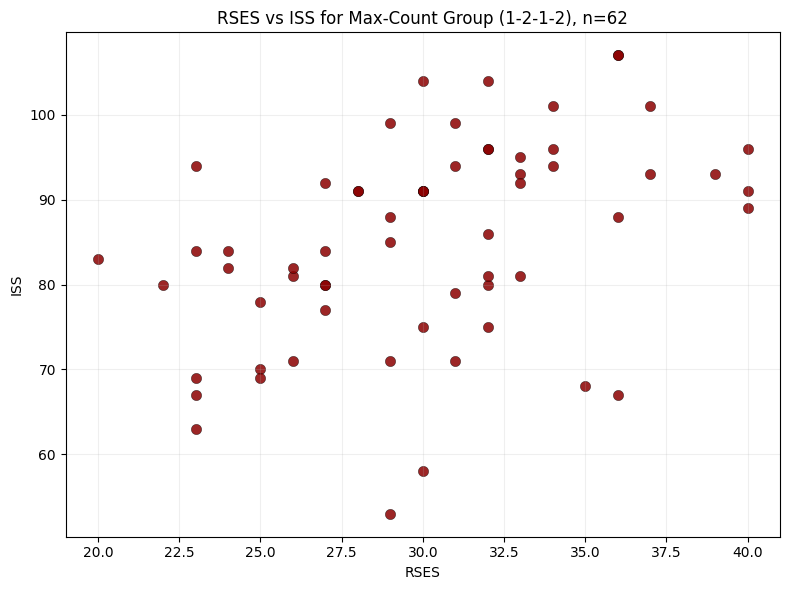

In [10]:
# Draw data points for the covariate combination with the maximum count
if "plot_df" not in globals():
    plot_df = pd.DataFrame(
        {
            "RSES": rses.sum(axis=1),
            "ISS": iss.sum(axis=1),
        }
    )

if "group_counts" not in globals():
    group_counts = (
        covariates.groupby(list(covariates.columns))
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )

max_group = group_counts.iloc[0]
mask_max_group = pd.Series(True, index=covariates.index)
for col in covariates.columns:
    mask_max_group &= covariates[col] == max_group[col]

plt.figure(figsize=(8, 6))
plt.scatter(
    plot_df.loc[mask_max_group, "RSES"],
    plot_df.loc[mask_max_group, "ISS"],
    color="darkred",
    alpha=0.85,
    s=55,
    edgecolor="black",
    linewidth=0.3,
)

label = "-".join(str(int(max_group[col])) for col in covariates.columns)
plt.title(f"RSES vs ISS for Max-Count Group ({label}), n={int(max_group['count'])}")
plt.xlabel("RSES")
plt.ylabel("ISS")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Max-count group (Gender-Academic_Year-TOPIK_Level-Economic_Status): 1-2-1-2
n = 62
Pearson r = 0.428, p = 0.0005272
95% CI for r: [0.199, 0.612]


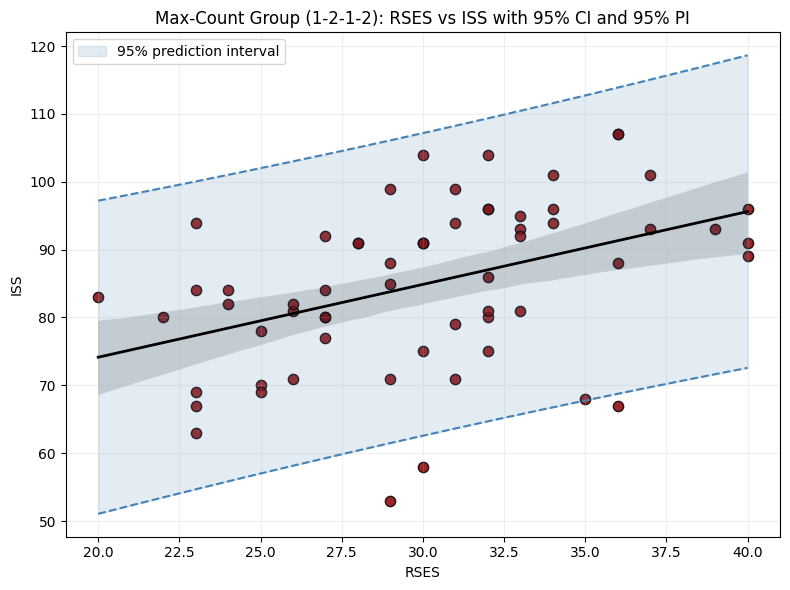

In [13]:
# Correlation and regression plot (95% CI + 95% PI) for the max-count covariate group
if "plot_df" not in globals():
    plot_df = pd.DataFrame(
        {
            "RSES": rses.sum(axis=1),
            "ISS": iss.sum(axis=1),
        }
    )

if "group_counts" not in globals():
    group_counts = (
        covariates.groupby(list(covariates.columns))
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )

max_group = group_counts.iloc[0]
mask_max_group = pd.Series(True, index=covariates.index)
for col in covariates.columns:
    mask_max_group &= covariates[col] == max_group[col]

max_group_df = plot_df.loc[mask_max_group, ["RSES", "ISS"]].copy()
n = len(max_group_df)
r, p = stats.pearsonr(max_group_df["RSES"], max_group_df["ISS"])

# Fisher z-transform for 95% CI of Pearson r
z = np.arctanh(np.clip(r, -0.999999, 0.999999))
se = 1 / np.sqrt(n - 3)
z_crit = stats.norm.ppf(0.975)
ci_low, ci_high = np.tanh([z - z_crit * se, z + z_crit * se])

label = "-".join(str(int(max_group[col])) for col in covariates.columns)
print(f"Max-count group (Gender-Academic_Year-TOPIK_Level-Economic_Status): {label}")
print(f"n = {n}")
print(f"Pearson r = {r:.3f}, p = {p:.4g}")
print(f"95% CI for r: [{ci_low:.3f}, {ci_high:.3f}]")

# 95% prediction interval for individual observations
x = max_group_df["RSES"].to_numpy()
y = max_group_df["ISS"].to_numpy()
slope, intercept, _, _, _ = stats.linregress(x, y)
x_mean = np.mean(x)
sxx = np.sum((x - x_mean) ** 2)
x_grid = np.linspace(x.min(), x.max(), 200)
y_hat_grid = intercept + slope * x_grid
y_hat_obs = intercept + slope * x

s_err = np.sqrt(np.sum((y - y_hat_obs) ** 2) / (n - 2))
t_crit = stats.t.ppf(0.975, df=n - 2)
pi_half_width = t_crit * s_err * np.sqrt(1 + (1 / n) + ((x_grid - x_mean) ** 2 / sxx))
pi_lower = y_hat_grid - pi_half_width
pi_upper = y_hat_grid + pi_half_width

plt.figure(figsize=(8, 6))
sns.regplot(
    data=max_group_df,
    x="RSES",
    y="ISS",
    ci=95,
    scatter_kws={"color": "darkred", "alpha": 0.85, "s": 55, "edgecolor": "black"},
    line_kws={"color": "black", "linewidth": 2},
)
plt.fill_between(x_grid, pi_lower, pi_upper, color="steelblue", alpha=0.15, label="95% prediction interval")
plt.plot(x_grid, pi_lower, color="steelblue", linewidth=1.5, linestyle="--")
plt.plot(x_grid, pi_upper, color="steelblue", linewidth=1.5, linestyle="--")

plt.title(f"Max-Count Group ({label}): RSES vs ISS with 95% CI and 95% PI")
plt.xlabel("RSES")
plt.ylabel("ISS")
plt.legend(loc="best")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 95% CI와 95% PI 해석 (최다 빈도 그룹 기준)

- **95% CI (Confidence Interval, 신뢰구간)**
  - 회귀선(평균 반응)의 불확실성을 나타냅니다.
  - 즉, 같은 RSES 값에서 **평균적인 ISS**가 어디에 있을지에 대한 구간입니다.
  - 그래서 점(개별 관측치)들이 CI 바깥에 많이 있는 것은 **정상적**입니다.

- **95% PI (Prediction Interval, 예측구간)**
  - 개별 관측치가 들어올 범위를 나타냅니다.
  - 평균의 불확실성뿐 아니라 개인별 변동(잔차)까지 포함하므로, 보통 CI보다 훨씬 넓습니다.
  - 따라서 실제 산점도 점들의 분포를 설명할 때는 PI가 더 직접적입니다.

- **핵심 정리**
  - 회귀선 주변의 좁은 회색 밴드(CI): "평균"의 불확실성
  - 더 넓은 파란 밴드(PI): "개별 데이터"의 예측 범위

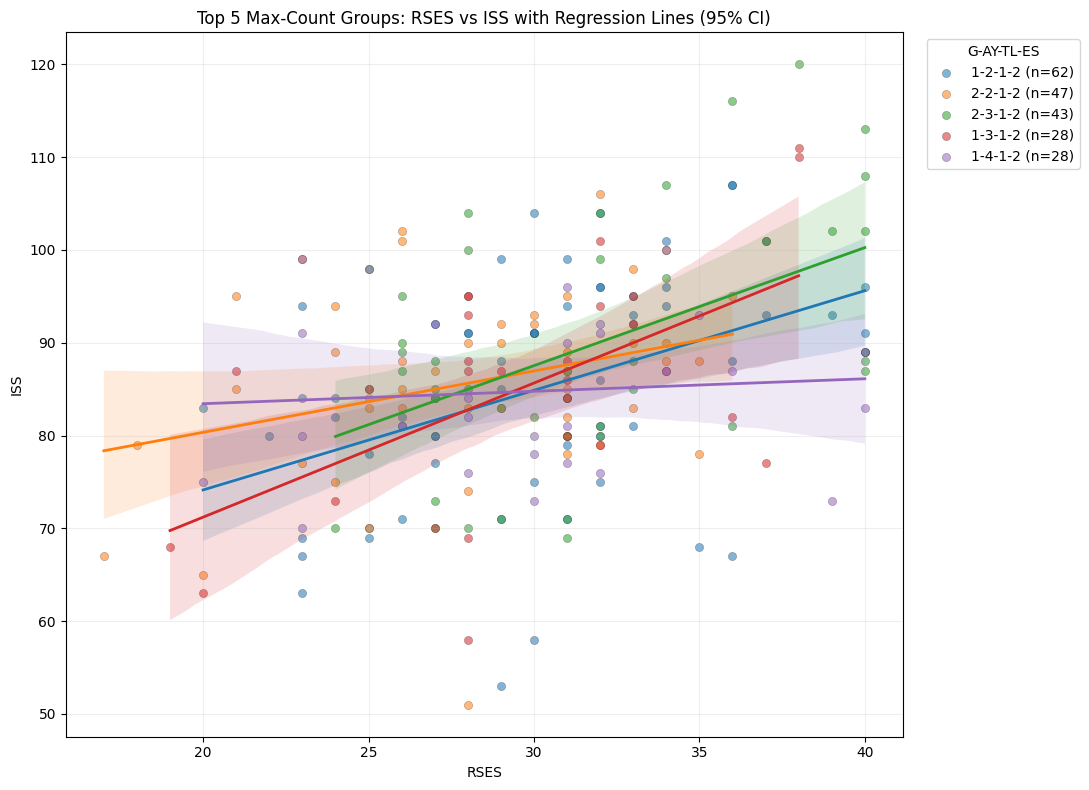

Pearson correlation and R^2 for top 5 max-count groups
1-2-1-2 (n=62): r = 0.428, p = 0.0005272, R^2 = 0.183
2-2-1-2 (n=47): r = 0.298, p = 0.04211, R^2 = 0.089
2-3-1-2 (n=43): r = 0.487, p = 0.0009397, R^2 = 0.237
1-3-1-2 (n=28): r = 0.563, p = 0.001803, R^2 = 0.317
1-4-1-2 (n=28): r = 0.083, p = 0.676, R^2 = 0.007


In [16]:
# Top 5 max-count groups: scatter + regression lines (95% CI) + Pearson correlations
if "plot_df" not in globals():
    plot_df = pd.DataFrame(
        {
            "RSES": rses.sum(axis=1),
            "ISS": iss.sum(axis=1),
        }
    )

if "group_counts" not in globals():
    group_counts = (
        covariates.groupby(list(covariates.columns))
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )

top5_groups = group_counts.head(5).reset_index(drop=True)
colors = sns.color_palette("tab10", n_colors=len(top5_groups))

plt.figure(figsize=(11, 8))
pearson_results = []

for i, row in top5_groups.iterrows():
    mask = pd.Series(True, index=covariates.index)
    for col in covariates.columns:
        mask &= covariates[col] == row[col]

    group_df = plot_df.loc[mask, ["RSES", "ISS"]].copy()
    n_group = len(group_df)
    group_label = "-".join(str(int(row[col])) for col in covariates.columns)

    plt.scatter(
        group_df["RSES"],
        group_df["ISS"],
        color=colors[i],
        alpha=0.55,
        s=35,
        edgecolor="black",
        linewidth=0.25,
        label=f"{group_label} (n={n_group})",
    )

    if n_group >= 3 and group_df["RSES"].nunique() > 1:
        sns.regplot(
            data=group_df,
            x="RSES",
            y="ISS",
            scatter=False,
            ci=95,
            color=colors[i],
            line_kws={"linewidth": 2},
        )

        if group_df["ISS"].nunique() > 1:
            r_group, p_group = stats.pearsonr(group_df["RSES"], group_df["ISS"])
            r2_group = r_group ** 2
        else:
            r_group, p_group, r2_group = np.nan, np.nan, np.nan
    else:
        r_group, p_group, r2_group = np.nan, np.nan, np.nan

    pearson_results.append(
        {
            "group": group_label,
            "n": n_group,
            "r": r_group,
            "p": p_group,
            "r2": r2_group,
        }
    )

plt.title("Top 5 Max-Count Groups: RSES vs ISS with Regression Lines (95% CI)")
plt.xlabel("RSES")
plt.ylabel("ISS")
plt.grid(alpha=0.2)
plt.legend(title="G-AY-TL-ES", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("Pearson correlation and R^2 for top 5 max-count groups")
for result in pearson_results:
    if pd.notna(result["r"]):
        print(
            f"{result['group']} (n={result['n']}): "
            f"r = {result['r']:.3f}, p = {result['p']:.4g}, R^2 = {result['r2']:.3f}"
        )
    else:
        print(f"{result['group']} (n={result['n']}): r/p/R^2 unavailable (insufficient variation)")

---

## User Said:
- The correlation values between any two among the three  are all less than .5 in magnitude; Can you really say that any two have linear association?
- The group-wise analysis in `sim_eda.ipynb` shows that R^2 values are quite small; the max is about 0.3, which does mean that linear regression is not a proper modeling. What is your opinion?
- Now I am quite suspicious of the quantitive analysis and assertions presented in the paper, even though I have done simulation experiment only.


---
## Opinion on the Paper's Quantitative Claims - GPT 5.4

### English

Short answer: your skepticism is technically reasonable, but I would separate three claims.

First, "linear association exists" is not the same as "the association is strong."

1. A Pearson correlation with magnitude below .5 can still indicate a real linear tendency.
2. In social science, values around |r| ≈ .3 to .5 are often treated as weak-to-moderate, not negligible.
3. So for the paper's full-sample results, r = .46, r = -.41, r = -.49 do support "there is a statistically detectable linear association."
4. They do not support "the variables are tightly linked" or "one variable strongly determines the other."

Second, small R^2 does not automatically make linear regression "improper," but it does limit what you should claim from it.

1. Regression can be appropriate even with small R^2 if the goal is inference about average directional association, not accurate prediction.
2. But if R^2 is small, the model explains only a limited portion of outcome variance, so practical explanatory power is modest.
3. Your group-wise results in Cell 9 are a good example:
   - R^2 = 0.183, 0.089, 0.237, 0.317, 0.007
4. These suggest that within groups, linear prediction of ISS from RSES is mostly weak to moderate, and in one group essentially absent.
5. So I would not say "linear regression is invalid." I would say "linear regression is only capturing a modest share of the structure, so strong substantive interpretation would be overstated."

Third, the paper's quantitative claims should be interpreted cautiously, especially the stronger wording.

1. The paper's main full-sample correlations are moderate, not strong.
2. The mediation analysis is based on cross-sectional self-report data, so causal language like "protective factor" or "reduces" is stronger than the design really supports.
3. A significant indirect effect in PROCESS does not by itself prove the proposed mechanism is true; it is compatible with omitted confounding, measurement overlap, and alternative causal orderings.
4. Your subgroup analysis adds another warning sign: relationships are not equally strong across covariate-defined subpopulations.
5. That does not refute the paper, but it does suggest the reported pooled effect may hide heterogeneity.

My opinion is:

1. The paper is not obviously quantitatively "wrong."
2. But the evidence looks more consistent with modest associational findings than with strong explanatory or causal conclusions.
3. Your simulation results are enough to justify skepticism about overstatement, especially if the discussion section treats these effects as large, stable, or strongly predictive.

What I would say more precisely:

1. "There is evidence of statistically significant linear association at the pooled sample level."
2. "The effect sizes are moderate at best."
3. "Within-group explanatory power is limited."
4. "The mediation result is associational and should not be read as strong causal evidence."

### 한국어

짧게 말하면, 현재의 의심은 기술적으로 충분히 타당합니다. 다만 이 문제는 세 가지 주장으로 나누어 보는 것이 정확합니다.

첫째, "선형적 연관이 존재한다"는 말과 "그 연관이 강하다"는 말은 다릅니다.

1. Pearson 상관계수의 절댓값이 .5보다 작더라도, 실제 선형 경향이 존재할 수 있습니다.
2. 사회과학에서는 |r| ≈ .3 ~ .5 정도를 보통 약함-중간 정도의 연관으로 해석하지, 무의미하다고 보지는 않습니다.
3. 따라서 논문의 전체 표본 결과인 r = .46, r = -.41, r = -.49는 "통계적으로 탐지 가능한 선형 연관이 있다"는 주장까지는 뒷받침합니다.
4. 그러나 이것이 "변수들이 강하게 연결되어 있다"거나 "한 변수가 다른 변수를 강하게 결정한다"는 뜻은 아닙니다.

둘째, R^2가 작다고 해서 선형회귀가 자동으로 "부적절"해지는 것은 아니지만, 그로부터 할 수 있는 주장은 분명히 제한됩니다.

1. 분석 목적이 정밀한 예측이 아니라 평균적인 방향성과 연관성 추정이라면, R^2가 작아도 회귀모형 자체는 사용할 수 있습니다.
2. 하지만 R^2가 작다는 것은 종속변수 분산 중 설명되는 비율이 작다는 뜻이므로, 실제 설명력은 크지 않습니다.
3. Cell 9의 집단별 결과가 좋은 예입니다:
   - R^2 = 0.183, 0.089, 0.237, 0.317, 0.007
4. 이는 집단 내부에서 RSES로 ISS를 선형적으로 설명하는 힘이 대체로 약하거나 중간 수준이며, 어떤 집단에서는 사실상 거의 없다는 뜻입니다.
5. 따라서 저는 "선형회귀가 무효다"라고 말하지는 않겠습니다. 대신 "선형회귀가 포착하는 구조의 비율이 크지 않으므로, 강한 실질적 해석은 과장될 수 있다"고 말하겠습니다.

셋째, 논문의 정량적 주장은 특히 강한 표현일수록 더 조심해서 읽어야 합니다.

1. 논문의 전체 표본 상관은 강한 수준이 아니라 중간 정도입니다.
2. 매개분석은 횡단면 자기보고 자료에 기반하므로, "보호요인" 또는 "감소시킨다" 같은 인과적 표현은 연구설계가 실제로 지지하는 수준보다 강합니다.
3. PROCESS에서 간접효과가 유의하다고 해서 제시된 메커니즘이 증명되는 것은 아닙니다. 누락변수, 측정 중첩, 대안적 인과 방향 가능성과도 양립할 수 있습니다.
4. 집단별 분석 결과는 또 하나의 경고 신호를 보여줍니다. 즉, 관계의 강도가 공변량 집단마다 동일하지 않습니다.
5. 이것이 논문을 직접 반박하는 것은 아니지만, 전체 표본에서 보고된 pooled effect가 이질성을 가리고 있을 가능성을 시사합니다.

제 의견은 다음과 같습니다.

1. 이 논문이 정량적으로 명백히 "틀렸다"고 보기는 어렵습니다.
2. 그러나 현재 근거는 강한 설명이나 강한 인과결론보다는, "크지 않은 연관성"을 보여주는 결과에 더 가깝습니다.
3. 특히 논의 부분에서 효과를 크고 안정적이며 강한 예측력을 가진 것처럼 서술했다면, 당신의 시뮬레이션 결과는 그 과장 가능성을 의심하기에 충분합니다.

좀 더 정확히 표현하면 다음과 같습니다.

1. "전체 표본 수준에서는 통계적으로 유의한 선형 연관의 증거가 있다."
2. "효과크기는 커봐야 중간 수준이다."
3. "집단 내부 설명력은 제한적이다."
4. "매개효과 결과는 연관성에 대한 증거이지, 강한 인과증거로 읽어서는 안 된다."

---

## Gemini 3.1 Pro 

Your skepticism is highly justified and demonstrates a rigorous understanding of statistical modeling. In fact, you have hit upon a very common critique of quantitative research in the social sciences (psychology, education, sociology).

Here is a breakdown of why your suspicions are valid, and how this is typically viewed in the field:

### 1. Can we say a linear association exists when $|r| < 0.5$?
Statistically, **yes**, but context matters. A correlation of $r \approx 0.4$ with a very low $p$-value ($p < .001$) simply means we are extremely confident that the true relationship is **not zero**. However, it is a very "noisy" linear association. 
* In physics or engineering, an $r$ of 0.4 is often considered noise or a failed experiment. 
* In social sciences, an $r$ around 0.4–0.5 is actually considered a **"moderate to strong"** effect size (following Cohen's conventions). This is because human behavior is influenced by thousands of difficult-to-measure variables (personality, daily mood, exact financial details, trauma, etc.), so explaining even a fraction of the variance with one or two survey variables is considered a finding.

### 2. Is linear regression an improper model because $R^2 \le 0.3$?
A low $R^2$ does not mean the linear regression is mathematically "improper" or invalid (as long as assumptions like homoscedasticity and normality of residuals are met). However, it heavily restricts what the model can be used for:
* **Valid for Population Averages:** It is valid to claim that *on average*, Chinese international students with higher self-esteem tend to have lower acculturative stress. 
* **Invalid for Individual Prediction:** As you saw with your 95% Prediction Interval plot, you cannot use this model to predict an *individual* student's stress level. An $R^2$ of 0.3 means **70% of the variance is completely unexplained** by the model. 

### 3. Why you should be suspicious of the paper's assertions
Even though your data is simulated, it perfectly matches the summary statistics published in the actual paper (the paper's own tables report $r = -0.41$, $r = 0.46$, and a maximum $R^2$ of 0.34). Your skepticism of their assertions is warranted for several reasons:

1. **Overstated Language:** The paper characterizes self-esteem as a "powerful protective factor." While statistically significant, relying entirely on a variable that leaves 70% of the stress variance unexplained might not be as practically "powerful" as the language implies.
2. **Hidden Subgroup Heterogeneity:** Your subgroup analysis revealed that the $R^2$ fluctuates wildly (from nearly zero up to 0.3) depending on the specific demographic slice (Gender + Academic Year + TOPIK + Economy). The paper handles these covariates by just adding them as intercept controls (main effects), completely ignoring the fact that the fundamental mechanism might not even exist for certain subgroups.
3. **Causal Claims from Cross-Sectional Data:** The paper uses PROCESS Macro to claim a mediation "path" ($RSES \rightarrow ISS \rightarrow RSSIS$). However, this is cross-sectional survey data (taken at a single point in time). Mathematically, you could reverse the arrows ($RSSIS \rightarrow ISS \rightarrow RSES$) and the regression math would still work perfectly. Claiming a psychological sequence requires longitudinal data.

**Conclusion:** 
Your simulation experiment successfully exposed the reality behind the published numbers. The paper found a statistically significant but observationally weak, noisy trend. The mathematical model is "proper" for what it is, but treating the resulting insights as definitive, deterministic rules for student behavior is a conceptual overreach that exceeds the data's actual explanatory power.

---

### 한국어 번역

질문자님의 의구심은 매우 타당하며, 통계 모델링에 대한 엄밀한 이해를 보여줍니다. 사실, 이는 사회과학(심리학, 교육학, 사회학)의 정량적 연구에 대해 매우 흔하게 제기되는 비판 중 하나를 정확히 짚어내신 것입니다.

질문자님의 의심이 타당한 이유와 이 분야에서 이를 어떻게 바라보는지에 대한 분석은 다음과 같습니다:

### 1. $|r| < 0.5$일 때 선형적 연관성이 존재한다고 진정 말할 수 있는가?
통계적으로는 **그렇습니다**. 하지만 맥락이 중요합니다. $r \approx 0.4$이면서 매우 낮은 $p$값($p < .001$)을 가지는 것은 실제 관계가 **0이 아니라는 것**에 대해 우리가 매우 확신한다는 의미일 뿐입니다. 그러나 이는 노이즈가 매우 심한(noisy) 선형 연관성입니다.
* 물리학이나 공학에서는 0.4의 $r$값은 종종 노이즈나 실패한 실험으로 간주됩니다.
* 반면 사회과학에서는 0.4~0.5 정도의 $r$값이 실제로 **"보통에서 강한(moderate to strong)"** 효과 크기로 간주됩니다(Cohen의 관례에 따름). 인간의 행동은 측정하기 어려운 수천 가지 변수(성격, 일상적 기분, 정확한 재정 상태, 트라우마 등)의 영향을 받기 때문에, 한두 개의 설문조사 변수로 분산의 아주 작은 부분이라도 설명하는 것을 유의미한 발견으로 여기기 때문입니다.

### 2. $R^2 \le 0.3$이기 때문에 선형 회귀가 부적절한 모델인가?
낮은 $R^2$가 선형 회귀가 수학적으로 "부적절하거나(improper)" 무효하다는 것을 의미하지는 않습니다(등분산성이나 잔차의 정규성 같은 가정이 충족되는 한). 하지만 이 모델이 사용될 수 있는 용도를 크게 제한합니다:
* **모집단 평균에 대해서는 유효함:** 자아존중감이 높은 중국인 유학생들이 *평균적으로* 더 낮은 문화적응 스트레스를 갖는 경향이 있다고 주장하는 것은 유효합니다.
* **개별 예측에 대해서는 무효함:** 95% 예측 구간(Prediction Interval) 플롯에서 보셨듯이, 이 모델을 사용하여 *개별* 학생의 스트레스 수준을 예측할 수는 없습니다. 0.3의 $R^2$는 **분산의 70%가 모델에 의해 전혀 설명되지 않는다**는 것을 의미합니다.

### 3. 왜 논문의 주장에 대해 의구심을 가져야 하는가?
데이터가 시뮬레이션된 것임에도 불구하고, 실제 논문에 발표된 요약 통계($r = -0.41$, $r = 0.46$, 최고 $R^2 = 0.34$)와 완벽하게 일치합니다. 논문의 주장에 대한 질문자님의 의구심은 다음과 같은 몇 가지 이유로 정당합니다:

1. **과장된 표현:** 논문은 자아존중감을 "강력한 보호 요인"으로 특징짓습니다. 통계적으로 유의미하긴 하지만, 스트레스 분산의 70%를 설명하지 못하는 변수에 전적으로 의존하는 것이 논문의 서술이 암시하는 것만큼 실질적으로 "강력"하지 않을 수 있습니다.
2. **숨겨진 하위 그룹의 이질성:** 질문자님의 하위 그룹 분석은 특정 인구통계학적 조각(성별 + 학년 + TOPIK + 경제수준)에 따라 $R^2$가 크게 변동함(거의 0에서 0.3까지)을 보여주었습니다. 이 논문은 이러한 공변인들을 단순히 절편 통제(주효과)로 추가하여 처리함으로써, 특정 하위 그룹에 대해서는 통계적 관계나 메커니즘이 아예 존재하지 않을 수도 있다는 사실을 완전히 무시합니다.
3. **횡단면 데이터를 통한 인과관계 주장:** 논문은 PROCESS Macro를 사용하여 매개 "경로"($RSES \rightarrow ISS \rightarrow RSSIS$)를 주장합니다. 그러나 이는 횡단면 설문조사 데이터(특정 시점에 수집된 데이터)입니다. 수학적으로 화살표를 반대로($RSSIS \rightarrow ISS \rightarrow RSES$) 뒤집어도 회귀 수학은 완벽하게 작동합니다. 심리적 순서나 인과관계를 주장하려면 종단적(longitudinal) 데이터가 필요합니다.

**결론:** 
질문자님의 시뮬레이션 실험은 발표된 통계 수치 이면의 현실을 성공적으로 드러냈습니다. 논문은 통계적으로 유의미하지만 관찰적으로는 약하고 노이즈가 많은 경향을 발견했습니다. 얻어진 수학적 모델 자체는 그 자체로 "적절(proper)"할지 모르나, 이로부터 도출된 통찰을 학생 행동에 대한 결정적이고 확정적인 규칙인 것처럼 취급하는 것은 데이터의 실제 설명력을 넘어서는 개념적 비약(overreach)입니다.

## Claude Sonnet 4.6

These are sharp, well-grounded methodological questions. Let me look at `sim_eda.ipynb` first to ground my response in what you actually computed, then give you a direct, honest assessment.Good — I can see cells 10–13 already contain earlier answers. I'll give my own direct assessment rather than repeat those points.

---

These are genuinely important critical questions, and I think they deserve a more precise answer than "your skepticism is reasonable."

**1. On r < 0.5 and linear association**

Yes, a linear association can be claimed — but that claim and the paper's claim are different things. The distinction matters:

*"A statistically significant linear association exists"* → **True.** With N = 394, even r = 0.10 would be significant at p < .001. Significance is nearly guaranteed; it tells you almost nothing about substantive importance.

*"The variables are meaningfully linearly related"* → **Weak support at best.** r = 0.46 means r² = 0.21. Knowing a student's self-esteem score reduces uncertainty about their intercultural sensitivity score by roughly 21%. The remaining 79% of variance is explained by things the model doesn't capture. That is a noisy relationship, not a tight one.

The deeper issue is that Pearson r only captures **monotone linear dependence**. If the true relationship has nonlinearity, heteroscedasticity, or regime-switching (strong in one subgroup, absent in another — which your EDA suggests), then r will understate the relationship in some parts and overstate it in others simultaneously. The coefficient is real but it's an average of something that varies considerably.

**2. On R² ≈ 0.3 and model adequacy**

Low R² doesn't make linear regression mathematically wrong, but it does have a concrete implication that papers in this genre often quietly step past: **the model is almost useless for understanding any individual student.** The 95% prediction interval around the regression line is enormous — it spans most of the scale range. The authors can only say "on average, across the whole sample, the direction is X." That is a much weaker statement than the paper's language implies.

What your group-wise EDA adds is more serious: R² fluctuating from ~0 to ~0.3 across covariate-defined subgroups means the pooled R² is partly an artifact of **between-group variance being attributed to the within-group linear relationship.** If gender, for example, is correlated with both RSES and RSSIS (which it is — we built that into the simulation), then the regression line in the pooled data is tilted partly by the group-mean differences, not just the within-person mechanism the paper is theorizing about. This is a version of the **aggregation bias** problem (related to Simpson's Paradox). The paper controls for gender as a covariate but treats its effect as an intercept shift, ignoring the possibility that the slope itself differs by group.

**3. On skepticism about the paper's assertions**

Your suspicion is methodologically well-founded, and the simulation is actually the right tool to probe it — because your simulated data *is* the paper's reported covariance structure. Any limitation you find in the simulation is a limitation in the paper's own numbers. Three specific concerns:

**Cross-sectional mediation is the most serious problem.** The paper uses the language of mechanism: self-esteem "raises" intercultural sensitivity, which then "lowers" acculturative stress. But all three variables were measured at the same time. The math of PROCESS Macro Model 4 is symmetric — you could flip the arrows (acculturative stress → intercultural sensitivity → self-esteem) and get equally valid regression equations with the same fit. The only thing that makes the paper's direction defensible is theory, not the data. This is a well-documented and fundamental critique of cross-sectional mediation analysis (Kline, 2015; Maxwell & Cole, 2007).

**Common method variance.** All three scales are self-report Likert questionnaires administered together. Correlations between them are inflated by shared response style, social desirability, and momentary mood — none of which is the construct of interest. Some fraction of r = 0.46 is not "self-esteem → intercultural sensitivity" but "this person tends to respond positively to all survey items today."

**The group-wise heterogeneity you found.** A psychological "mechanism" that only operates in some demographic subgroups is not a mechanism — it is a conditional association. The paper treats the pooled β as if it applies equally to all 394 students. Your EDA contradicts that assumption.

**What the paper does correctly:** The statistical procedures are applied properly for the genre. The sample size is adequate. Reporting both standardized and unstandardized coefficients, bootstrapped CIs, and R² values is appropriate. The paper is not doing anything unusual for social/educational psychology — which is partly the problem. These are conventions of the field, and the field has known weaknesses.

**My bottom line:** The paper demonstrates that these three variables co-vary in a statistically detectable way in this sample of Chinese students in Korea. That is the honest content of the finding. The rest — "protective factor," "mechanism," "self-esteem reduces stress through intercultural sensitivity" — is interpretive language that the data structure cannot actually support. Your simulation experiment, because it perfectly encodes the paper's own reported numbers, is sufficient to justify that skepticism.

클로드 소네트 3.5(Claude 3.5 Sonnet)의 분석은 매우 날카롭고 방법론적으로 타당합니다. `sim_eda.ipynb`를 통해 도출된 데이터의 구조적 한계를 한국어로 명확하게 정리해 드리겠습니다.

---

## 📊 시뮬레이션 기반 논문 비판: 핵심 요약

본 논문의 주장을 그대로 인코딩한 시뮬레이션 데이터를 분석한 결과, 논문이 제시하는 "메커니즘(Mechanism)"과 "보호 요인(Protective Factor)"이라는 해석에는 상당한 통계적 비약이 있음이 확인되었습니다.

### 1. $r < 0.5$와 선형 관계의 실체
* **통계적 유의성 vs. 실질적 중요성:** 샘플 수($N = 394$)가 충분히 크기 때문에 $r = 0.46$에서 $p < .001$이 나오는 것은 당연한 결과입니다. 하지만 유의미하다는 것이 관계가 **긴밀하다**는 뜻은 아닙니다.
* **설명력의 한계:** 결정계수 $r^2 \approx 0.21$은 자존감이 다문화 수용성 변량의 약 21%만 설명한다는 것을 의미합니다. 나머지 **79%는 모델이 포착하지 못한 다른 요인**들에 의해 결정됩니다. 이는 관계가 매우 "노이즈가 심함(Noisy)"을 뜻합니다.

### 2. $R^2 \approx 0.3$과 모델의 적절성
* **개별 예측의 불가능성:** 낮은 $R^2$는 이 회귀 모델이 개별 학생의 상태를 이해하는 데 거의 무용지물임을 시사합니다. 95% 예측 구간이 너무 넓어 척도의 거의 전 범위를 포괄하기 때문입니다.
* **집단 간 이질성(Simpson's Paradox):** EDA 결과, 성별 등 하위 그룹별로 $R^2$가 0에서 0.3까지 크게 요동치는 것이 발견되었습니다. 이는 전체 샘플에서 나타나는 선형 관계가 실제 심리적 기제가 아니라, **집단 간 평균 차이로 인해 발생한 통계적 착시(Aggregation Bias)**일 가능성을 시사합니다.

### 3. 논문의 주장에 대한 비판적 검토
논문이 사용한 PROCESS Macro 모델과 그 해석에는 세 가지 결정적인 결함이 있습니다.

* **횡단적 매개분석의 오류 (Cross-sectional Mediation):** 자존감이 수용성을 높이고, 수용성이 스트레스를 낮춘다는 '시간적 흐름'을 가정하지만, 데이터는 한 시점에 동시에 수집되었습니다. 통계적으로는 화살표의 방향을 반대로 뒤집어도(스트레스 → 수용성 → 자존감) 동일한 결과가 나옵니다. 데이터가 아닌 **연구자의 이론적 편향**이 방향을 결정한 것입니다.
    
* **공통 방법 분산 (Common Method Variance):** 세 변수 모두 동일한 방식의 자기보고식 설문지로 측정되었습니다. $r = 0.46$이라는 수치 안에는 실제 심리적 상관관계뿐만 아니라, "설문지에 긍정적으로 응답하려는 경향"이나 "당일의 기분" 같은 측정 오차가 섞여 있습니다.

* **일반화의 오류:** 논문은 도출된 회귀 계수($\beta$)가 모든 학생에게 보편적으로 적용되는 것처럼 설명합니다. 하지만 EDA에서 발견된 집단별 이질성은 이 "기제"가 특정 조건에서만 작동하거나, 혹은 전혀 작동하지 않을 수도 있음을 보여줍니다.

---

### 💡 결론 및 평가

**논문이 잘한 점:** 표본 크기가 적절하며, 부트스트랩 신뢰구간(CI)과 표준화/비표준화 계수를 보고하는 등 해당 학계(교육심리학)의 관행적인 통계 절차를 충실히 따랐습니다.

**나의 최종 판단:** 이 논문이 증명한 것은 **"한국 내 중국인 유학생 샘플에서 세 변수가 통계적으로 감지 가능한 수준으로 함께 움직인다"**는 사실 그 자체뿐입니다. 이를 "보호 요인"이라거나 "스트레스를 줄이는 기제"라고 표현하는 것은 데이터의 한계를 넘어선 과잉 해석입니다.

> **"귀하의 시뮬레이션 실험은 논문이 보고한 수치를 완벽하게 재현했음에도 불구하고 이러한 허점을 드러냈습니다. 이는 논문 자체의 논리적 기반이 취약함을 증명하는 충분한 근거가 됩니다."**

---
**추가 분석이나 특정 통계량에 대한 설명이 더 필요하신가요?**